# Analyse van hele netwek


## data laden en preprocessen




In [14]:
import pandas as pd
import networkx as nx
import re
from collections import Counter
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import random
from scipy import stats


In [2]:
%%time
df= pd.read_csv('LidoLinks.csv.gz', header=None)
print(df.shape)
df.head()


(7355861, 2)
CPU times: total: 10.6 s
Wall time: 10.7 s


,0,1
0,jurisprudentie/id/ECLI:NL:RBAMS:2015:6776,bwb/id/BWBR0001854/2967974/1984-05-01/1984-05-01
1,jurisprudentie/id/ECLI:NL:RBOBR:2018:4470,bwb/id/BWBR0005290/2913524/2018-07-28/2018-07-28
2,jurisprudentie/id/ECLI:NL:RBAMS:2019:4496,bwb/id/BWBR0001854/2963144/1986-05-19/1986-05-19
3,jurisprudentie/id/ECLI:NL:RBOVE:2024:2366,bwb/id/BWBR0001827/3178144/2002-01-01/2002-01-01
4,jurisprudentie/id/ECLI:NL:RBUTR:2006:BA7009,bwb/id/BWBR0002375/2060994/2006-01-01/2006-01-01


In [3]:
%%time
# haal de datums van de id's af. Dit werkt alleen op de bwb/id knopen
df[1]=df[1].str.replace(r'(bwb.*?)(/[-0-9]+)?/[-0-9]+$',r'\1',regex=True) 
df[0]=df[0].str.replace(r'(bwb.*?)(/[-0-9]+)?/[-0-9]+$',r'\1',regex=True) 

CPU times: total: 25.2 s
Wall time: 25.5 s


In [4]:
df['groep_s'] = df[0].str.replace(r'/id.*', r'', regex=True)
df['groep_t'] = df[1].str.replace(r'/id.*', r'', regex=True)

In [19]:
YEAR_REGEX = re.compile(r'ECLI[.:]NL[.:][A-Z]+[.:](\d{4})[.:]')

def ecli_year(u):
    m = YEAR_REGEX.search(str(u))
    return int(m.group(1)) if m else None

bron_hr = df[0].astype(str).str.contains(r'ECLI[.:]NL[.:]HR[.:]', na=False) 
target_hr = df[1].astype(str).str.contains(r'ECLI[.:]NL[.:]HR[.:]', na=False)

print(f'edges met HR als bron: {bron_hr.sum()}')
print(f'edges met HR als target: {target_hr.sum()}')
print(f'edges HR->HR: {(bron_hr & target_hr).sum()}')
print(f'edges HR->iets anders: {(bron_hr & ~target_hr).sum()}')
print(f'edges iets anders->HR: {(~bron_hr & target_hr).sum()}')

edges met HR als bron: 263940
edges met HR als target: 466924
edges HR->HR: 26257
edges HR->iets anders: 237683
edges iets anders->HR: 440667


In [20]:
#   G_all_HR:  elke edge die HR aan beide uiteinden heeft (HR--HR)
#   G_HR_HR:   alleen HR->HR
#   G_repro:   G_HR_HR beperkt tot 1965-2008 
#   G_ext:     G_HR_HR alle jaren t/m heden

WINKELS_START, WINKELS_END = 1965, 2008

df_hrhr = df[bron_hr & target_hr].copy()
df_hrhr['src_year'] = df_hrhr[0].map(ecli_year)
df_hrhr['tgt_year'] = df_hrhr[1].map(ecli_year)


# alle edges waar bron HR is
df_all_hr = df[bron_hr].copy()

G_all_HR = nx.from_pandas_edgelist(
    df_all_hr, source=0, target=1, create_using=nx.DiGraph()
)

# alle jaren, incl. pre-1965
G_HR_HR = nx.from_pandas_edgelist(df_hrhr, source=0, target=1, create_using=nx.DiGraph()) 

# alleen 1965–2008
df_repro = df_hrhr[
    df_hrhr['src_year'].between(WINKELS_START, WINKELS_END) &
    df_hrhr['tgt_year'].between(WINKELS_START, WINKELS_END)
]
G_repro = nx.from_pandas_edgelist(df_repro, source=0, target=1, create_using=nx.DiGraph())

# 1965–heden
df_ext = df_hrhr[
    (df_hrhr['src_year'] >= WINKELS_START) &
    (df_hrhr['tgt_year'] >= WINKELS_START)
]
G_ext = nx.from_pandas_edgelist(df_ext, source=0, target=1, create_using=nx.DiGraph())

## 2 Hele netwerk

In [5]:
G = nx.from_pandas_edgelist(df, source=0, target=1, create_using=nx.DiGraph())
print(f'hele netwerk: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges')
print(f'dichtheid: {nx.density(G):.8f}')

hele netwerk: 1,628,457 nodes, 6,917,225 edges
dichtheid: 0.00000261


## 3. Homofilie 

In sociale netwerken is er homofilie: vrienden lijken op elkaar. Bij een fractie $p$ van de knopen is type X en fractie $q=1-p$ type Y:

Onder willekeurige koppeling wordt verwacht dat het percentage cross-type edges gelijk is aan $2pq$. Als dat significant lager is, hebben we homofilie. Als het hoger is, is er inverse homofilie (Easley & Kleinberg).

In [6]:
types = df['groep_s'].value_counts()
types_total = (df['groep_s'].value_counts().add(df['groep_t'].value_counts(), fill_value=0))
p_i = types_total / types_total.sum()





## 4. Clustering coefficient 

## 5. Gemiddelde padlengte & small-world

## 6. Componentenanalyse en robuustheid

In [7]:
# componenten
wcc_sizes = sorted((len(c) for c in nx.weakly_connected_components(G)), reverse=True)
scc_sizes = sorted((len(c) for c in nx.strongly_connected_components(G)), reverse=True)
print(f'wcc: {len(wcc_sizes):,}   grootste: {wcc_sizes[0]:,}   ({wcc_sizes[0]/G.number_of_nodes():.1%})')
print(f'scc: {len(scc_sizes):,}   grootste: {scc_sizes[0]:,}   ({scc_sizes[0]/G.number_of_nodes():.1%})')

# Verdeling van WCC-groottes, GIant component (Easley en Kleinberg)
pd.Series(wcc_sizes).value_counts().sort_index(ascending=False).head(10)

wcc: 39,182   grootste: 1,504,497   (92.4%)
scc: 1,504,555   grootste: 608   (0.0%)


1504497    1
223        1
210        1
167        1
146        1
137        1
131        1
123        2
120        1
117        1
Name: count, dtype: int64

WCC: er is 1 rheel groot component van 1.504.497 knopen, 92,4 % van het netwerk. De andere 7,6 % is verspreid over 39.181 andere kleine componenten. "giant component" dat Easley & Kleinberg beschrijven: zodra je de richting negeert, blijkt een groot deel van de nodes via paden met elkaar verbonden te zijn.

SCC: 1.504.555 componenten waarvan de grootste maar 608 nodes heeft, 0,004 %. In een SCC moet je vanuit elke knoop elke andere knoop bereiken en weer terug. Dit kan in citatienetwerken bijna nooit, omdat citaties tijdsgericht zijn: een uitspraak uit 2010 kan een uitspraak uit 1995 citeren, maar niet andersom. 

In [8]:
# robuustheid

def node_order(H, strategy, seed=42):
    U = H.to_undirected()

    if strategy == 'random':
        rng = np.random.default_rng(seed)
        return list(rng.permutation(list(U.nodes)))

    if strategy == 'degree':
        return [n for n, d in sorted(U.degree, key=lambda x: x[1], reverse=True)]

    if strategy == 'pagerank':
        pr = nx.pagerank(H)
        return sorted(H.nodes, key=lambda n: pr.get(n, 0), reverse=True)


def robustness(H, strategy, steps=15, seed=42):
    U = H.to_undirected().copy()
    order = node_order(H, strategy, seed)
    



# curves = pd.concat([
#     robustness(G_ext, 'random'),
#     robustness(G_ext, 'degree'),
#     robustness(G_ext, 'pagerank')
# ])




## 7. Temporele groei en preferential attachment 

930,685 knopen met jaartal (totaal 1,628,457)


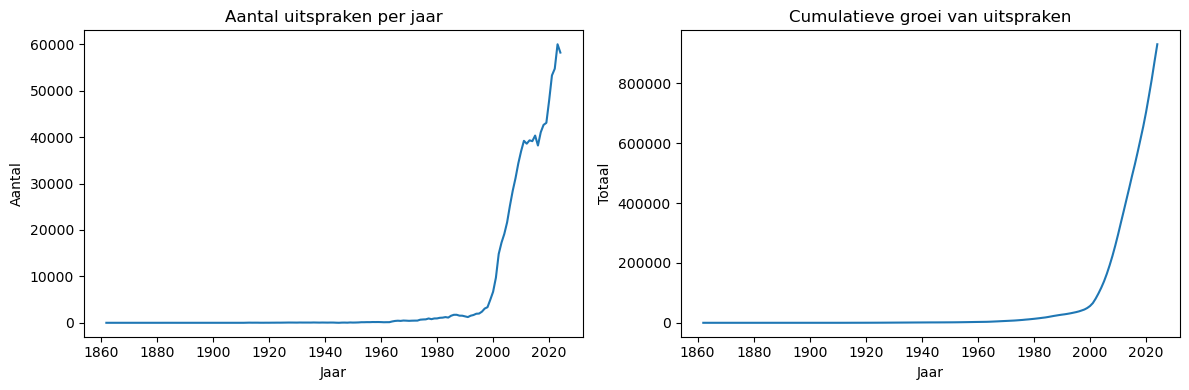

In [9]:
# jaartallen uit ECLI halen
def ecli_year(uri):
    m = re.search(r'ECLI[\.:][A-Z]{2}[\.:][A-Z]+[\.:](\d{4})', str(uri))
    if m: return int(m.group(1))
    return None

years = pd.Series({n: ecli_year(n) for n in G.nodes})
years = years.dropna()
print(f'{len(years):,} knopen met jaartal (totaal {G.number_of_nodes():,})')

y_counts = years.value_counts().sort_index()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# aantal uitspraken per jaar
ax1.plot(y_counts.index, y_counts.values)
ax1.set_title('Aantal uitspraken per jaar')
ax1.set_xlabel('Jaar')
ax1.set_ylabel('Aantal')

# cumulatieve groei
ax2.plot(y_counts.index, y_counts.cumsum())
ax2.set_title('Cumulatieve groei van uitspraken')
ax2.set_xlabel('Jaar')
ax2.set_ylabel('Totaal')

plt.tight_layout()
plt.show()

Het netwerk groeit exponentieel sinds de 2000, maar deze groei is het gevolg van digitalisering rechtspraak.nl en de invoering van ECLI in 2013, niet per se van een toename in rechterlijke productie zelf.

Voor de Winkels-vergelijking betekent dit dat zijn dataset van voor 2008 (15.053 NJ-arresten) waarschijnlijk completer is voor die periode dan onze dataset.

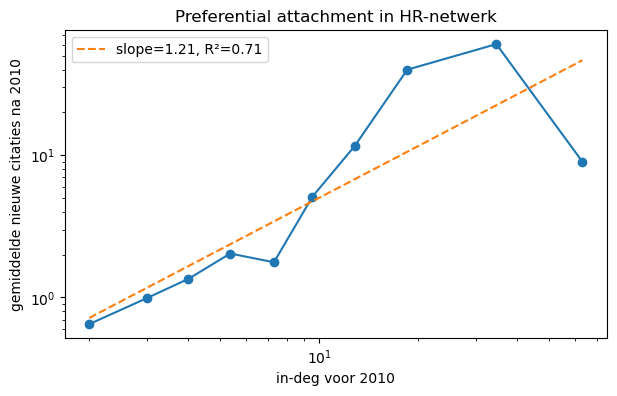

PA-exponent ≈ 1.21


In [40]:
# Preferential attachment
# krijgen uitspraken die al veel gecciteerd zijn later ook meer nieuwe citaties

def pref_attachment(G, split_year):
    rows = []

    for node in G.nodes:
        year = ecli_year(node)

        if year is None or year >= split_year:
            continue

        old_indeg = 0
        new_indeg = 0

        for source in G.predecessors(node):
            source_year = ecli_year(source)

            if source_year < split_year:
                old_indeg += 1 # citatie voor splitjjaar
            else:
                new_indeg += 1 #citatie na splitjaar

        if old_indeg > 0:
            rows.append({
                'old_indeg': old_indeg,
                'new_indeg': new_indeg
            })

    df_pa = pd.DataFrame(rows)

    bins = np.logspace(0, np.log10(max(df_pa['old_indeg'].max(), 2)), 15)
    df_pa['bin'] = pd.cut(df_pa['old_indeg'], bins=bins)

    agg = df_pa.groupby('bin', observed=True).agg(
        mean_k=('old_indeg', 'mean'),
        mean_gain=('new_indeg', 'mean')
    ).dropna()

    return agg

agg = pref_attachment(G_ext, split_year=2010)

plt.figure(figsize=(7, 4))
plt.loglog(agg['mean_k'], agg['mean_gain'].clip(lower=1e-3), marker='o')

x = np.log10(agg['mean_k'])
y = np.log10(agg['mean_gain'].clip(lower=1e-3))

slope, intercept, r, p, se = stats.linregress(x, y)

plt.loglog(
    agg['mean_k'],
    10**(intercept + slope*x),
    linestyle='--',
    label=f'slope={slope:.2f}, R²={r**2:.2f}'
)

plt.xlabel('in-deg voor 2010')
plt.ylabel('gemiddelde nieuwe citaties na 2010')
plt.title('Preferential attachment in HR-netwerk')
plt.legend()
plt.show()

print(f'PA-exponent ≈ {slope:.2f}')


Regressielijn op loglog schaal heeft PA exponent van ong 1.21. Het is groter dan 1 dus licht superlinear preferential atatachment. R² = 0.71 is redelijk maar niet heel hoog, vooral de hoogste indegree-bin valt onder de lijn. De relatie is dus geen perfecte power-law, maar wel rich get richer patroon


In [41]:
# Kleinberg copy mechanisme

## 8. Verandert citatie-gedrag door de tijd?

neemt het aantal uitgaande links per ecli toe door de tijd?

Waarnaar?

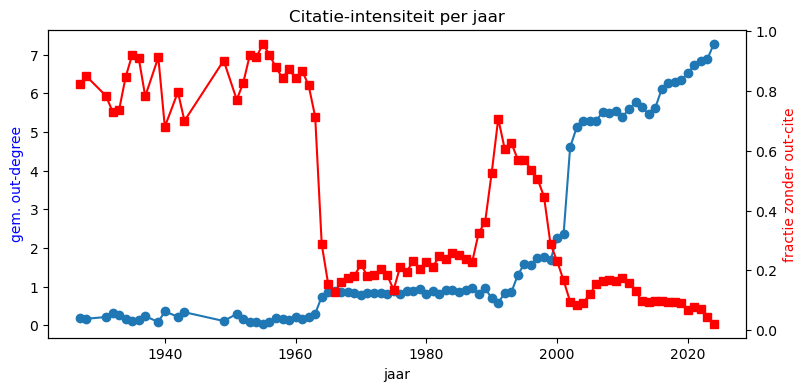

,n,mean_out,frac_no_out
year,,,
2010.0,36989,5.401822,0.174484
2011.0,39205,5.584364,0.158883
2012.0,38592,5.766117,0.131633
2013.0,39311,5.646282,0.096462
2014.0,39134,5.463024,0.092630
2015.0,40340,5.613609,0.098785
2016.0,38198,6.106131,0.098932
2017.0,41046,6.277737,0.095600
2018.0,42637,6.294979,0.093909


In [11]:
# out degree per jaar
out_by_year = pd.DataFrame({
    'year':    years.values,
    'out_deg': [G.out_degree(n) for n in years.index],
})

agg_year = out_by_year.groupby('year').agg(n=('out_deg','size'), mean_out=('out_deg','mean'), frac_no_out=('out_deg', lambda s: (s==0).mean()))


agg_year = agg_year[agg_year['n'] >= 50]


fig, ax1 = plt.subplots(figsize=(9,4))
ax1.plot(agg_year.index, agg_year['mean_out'], marker='o', label='gem. out-deg')
ax1.set_xlabel('jaar'); ax1.set_ylabel('gem. out-degree', color='blue')

ax2 = ax1.twinx()
ax2.plot(agg_year.index, agg_year['frac_no_out'], marker='s', color='red', label='frac zonder out-cite')
ax2.set_ylabel('fractie zonder out-cite', color='red')
ax1.set_title('Citatie-intensiteit per jaar')
plt.show()


agg_year.tail(15)

De citatie-intensiteit sinds 2000 heel sterk gegroeid, maar deze trend is door de digitalisering van rechtspraak.nl en invoering van ECLI.

In [12]:
# Target-samenstelling per jaar over de 5-6 hoofdgroepen



## 9. Rank-based friendship

In [ ]:
# 9. Rank-based friendship 

def doc_type(n):
    m = re.match(r'(^.*)/id(?:/|$)', n)
    return m.group(1) if m else n

def social_dist(u, v):
    ku, kv = doc_type(u), doc_type(v)
    if ku == kv:
        return 1
    return 2

# op een sample
sample_edges = random.Random(42).sample(list(G.edges), min(50000, G.number_of_edges()))
d_counts = Counter(social_dist(u, v) for u, v in sample_edges)
print('edges op social distance:', dict(d_counts))


edges op social distance: {2: 37750, 1: 12250}
